# Flow compensation across a multi-echo gradient-echo train

A multi-echo gradient echo (MEGRE) excites a slice once, encodes one line of k-space, and then
reads that line out **several times** — the readout gradient sweeps back and forth across
$k_x$, producing an echo on each traverse, so one excitation yields images at several echo times.
The decay of signal magnitude across those echo times gives $T_2^*$; the growth of signal *phase*
across them gives the field map that susceptibility-weighted imaging and quantitative
susceptibility mapping are built on. [`01_build`](01_build.ipynb) builds the train and
[`02_simulate_and_reconstruct`](02_simulate_and_reconstruct.ipynb) images with it.

Because those applications read the phase, anything else that writes phase is a confound — and
motion is the main one. A spin moving at constant velocity $v$ along an axis accumulates, by the
echo,

$$\phi \;=\; 2\pi \int_{t_0}^{t_\text{echo}} G(t)\, x(t)\, \mathrm{d}t
        \;=\; 2\pi\left[\, M_0\, x_0 \;+\; M_1\, v \,\right],
\qquad
M_n \;=\; \int_{t_0}^{t_\text{echo}} G(t)\,(t - t_0)^n\, \mathrm{d}t$$

where $t_0$ is the RF effective centre — the instant transverse magnetisation is created and the
instant its phase starts from — and $x(t) = x_0 + v\,(t-t_0)$. **Flow compensation**, or
first-moment nulling, is the design of the pre-echo gradients so that $M_1 = 0$, which removes the
velocity term and leaves only the position term the encoding wants.
[`gre_2d/03_flow_comp`](../gre_2d/03_flow_comp.ipynb) does this for a single-echo gradient echo.

A single-echo sequence has one echo, so $M_1 = 0$ is one condition and there is nothing to argue
about. A four-echo train has four echoes, and the gradients that produce echoes 2, 3 and 4 play
*after* echo 1 — so nulling $M_1$ at the first echo says nothing about the rest. **What "flow
compensated" means for a train is therefore a question about the sequence, not a detail of the
solver**, and this notebook measures the answer on the emitted waveform: the first moment at every
echo, on every axis, for both readout polarities.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pypulseq as pp

import seqcraft as sc

opts = pp.Opts(
    max_grad=40, grad_unit='mT/m',
    max_slew=150, slew_unit='T/m/s',
    B0=3.0,
    rf_dead_time=100e-6,
    rf_ringdown_time=30e-6,
    adc_dead_time=10e-6,
)

FOV_MM, MATRIX, THICKNESS_MM = 220.0, 64, 5.0
BANDWIDTH_HZ_PX, ECHOES = 500.0, 4

# Every measurement below uses a line well off the centre of k-space, so that `M0` on the
# phase-encode axis is the line's own non-zero `ky` rather than a value that happens to be zero.
LINE = MATRIX // 4

SEQ_DIR = Path('seq')
SEQ_DIR.mkdir(exist_ok=True)


def megre(polarity, **kwargs):
    return sc.modules.GRE2DTR(opts=opts, fov_mm=FOV_MM, matrix=(MATRIX, MATRIX),
                              thickness_mm=THICKNESS_MM, bandwidth_hz_px=BANDWIDTH_HZ_PX,
                              echoes=ECHOES, polarity=polarity, **kwargs)


def echo_times(kernel):
    '''Absolute instant of every echo, measured from the start of the repetition.

    `time_to_echo()` is the first echo of the train and `ro.te_s` locates the rest of them
    inside the readout block, so the offsets carry over unchanged.
    '''
    first = kernel.time_to_echo()
    return tuple(first + (t - kernel.ro.te_s[0]) for t in kernel.ro.te_s)


print(f'{ECHOES} echoes, {MATRIX}x{MATRIX}, {BANDWIDTH_HZ_PX:.0f} Hz/px, line {LINE} of {MATRIX}\n')
for polarity in ('monopolar', 'bipolar'):
    kernel = megre(polarity)
    t0 = kernel.exc.time_to_center()
    echoes = ', '.join(f'{(t - t0) * 1e3:.3f}' for t in echo_times(kernel))
    print(f'{polarity:>10}   echo spacing {kernel.ro.echo_spacing_s * 1e6:7.1f} us'
          f'   TE {echoes} ms')

/opt/homebrew/Caskroom/miniforge/base/envs/seqcraft-dev/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


4 echoes, 64x64, 500 Hz/px, line 16 of 64

 monopolar   echo spacing  2500.0 us   TE 3.114, 5.614, 8.114, 10.614 ms
   bipolar   echo spacing  2080.0 us   TE 3.126, 5.174, 7.286, 9.334 ms


---

## 1. Measuring a moment at every echo

The moment is a property of the waveform, so the way to read it is to integrate the events the
sequence actually plays. Two instants define each measurement and both need saying:

```text
integration interval   [t0, TE_n]   the gradient acts on the transverse signal over this
motion reference       t0           position and velocity are parameterised about this
```

The interval starts at the RF effective centre because that is when transverse magnetisation
exists — a slice-select lobe that plays *before* it dephases nothing. The reference is a choice,
and referencing to $t_0$ makes $M_1$ the velocity coefficient in the phase expression above.
Both are held fixed across the whole train here: **one origin, several endpoints**.

In [2]:
def moment(shot, order, axis, t0, end):
    '''M_n on one axis over [t0, end], referenced to t0.  Clips lobes straddling either instant.'''
    total = 0.0
    for start, event, _ in sc.flatten(shot):
        if getattr(event, 'channel', None) != axis:
            continue
        times, amps = sc.events.knots_of(event, start)
        if times.size < 2 or end <= times[0] or times[-1] <= t0:
            continue
        if times[0] < t0:
            cut = int(np.searchsorted(times, t0))
            edge = float(np.interp(t0, times, amps))
            times, amps = np.concatenate(([t0], times[cut:])), np.concatenate(([edge], amps[cut:]))
        if end < times[-1]:
            cut = int(np.searchsorted(times, end))
            edge = float(np.interp(end, times, amps))
            times, amps = np.concatenate((times[:cut], [end])), np.concatenate((amps[:cut], [edge]))
        total += sc.events.pwl_moment(times - t0, amps, order)
    return float(total)


def train(kernel, line=LINE):
    '''The emitted repetition, its RF effective centre, and the absolute instant of every echo.'''
    return kernel(line=line), kernel.exc.time_to_center(), echo_times(kernel)


def table(kernel, axes=('x', 'y', 'z'), line=LINE):
    shot, t0, echoes = train(kernel, line)
    print(f'{"echo":>5}{"TE / ms":>10}' + ''.join(f'{f"M0 {a} / (1/m)":>16}{f"M1 {a} / (s/m)":>16}'
                                                  for a in axes))
    for n, te in enumerate(echoes):
        row = ''.join(f'{moment(shot, 0, a, t0, te):16.4f}{moment(shot, 1, a, t0, te):16.6e}'
                      for a in axes)
        print(f'{n:>5}{(te - t0) * 1e3:10.3f}{row}')          # TE, i.e. measured from t0
    return np.array([[moment(shot, 1, a, t0, te) for te in echoes] for a in axes])

---

## 2. The uncompensated train

Nothing here asks for flow compensation. The zeroth moments are the encoding — $k_x = 0$ at every
echo, which is what makes it an echo; $k_y$ the line's own value; $k_z = 0$ from the slice
rephaser — and the first moments are whatever the waveform happens to produce.

In [3]:
uncompensated = {}
for polarity in ('monopolar', 'bipolar'):
    print(f'{polarity}, no flow compensation')
    uncompensated[polarity] = table(megre(polarity))
    print()

monopolar, no flow compensation
 echo   TE / ms    M0 x / (1/m)    M1 x / (s/m)    M0 y / (1/m)    M1 y / (s/m)    M0 z / (1/m)    M1 z / (s/m)
    0     3.114         -0.0000    1.183505e-01        -72.7273   -1.316364e-01          0.0000   -4.259556e-01
    1     5.614          0.0000    1.234496e-01        -72.7273   -1.316364e-01          0.0000   -4.259556e-01
    2     8.114          0.0000    1.285487e-01        -72.7273   -1.316364e-01          0.0000   -4.259556e-01
    3    10.614          0.0000    1.336477e-01        -72.7273   -1.316364e-01          0.0000   -4.259556e-01

bipolar, no flow compensation
 echo   TE / ms    M0 x / (1/m)    M1 x / (s/m)    M0 y / (1/m)    M1 y / (s/m)    M0 z / (1/m)    M1 z / (s/m)
    0     3.126         -0.0000    1.194443e-01        -72.7273   -1.316364e-01          0.0000   -4.259556e-01
    1     5.174         -0.0000   -3.189596e-02        -72.7273   -1.316364e-01          0.0000   -4.259556e-01
    2     7.286         -0.0000    1.2889

$M_0$ behaves identically in both: $k_x$ returns to zero at every echo, $k_y$ holds the line, $k_z$
stays rephased. That is the readout doing its job, and it is the same at echo 4 as at echo 1.

$M_1$ does not hold still, and the two polarities are unalike:

```text
monopolar   M1x climbs monotonically, by an equal step each echo
bipolar     M1x alternates in sign, and does not return to where it started
```

$M_1$ on `y` and `z`, by contrast, is the *same number at every echo* — large, but constant.

---

## 3. Asking for flow compensation

`flow_comp=` adds $M_1 = 0$ as a condition alongside the zeroth-moment condition each axis already
has. There is one echo in the design — the first — so this is a statement about the first echo,
and the question is what it does to the rest of the train.

In [4]:
FULL = sc.FlowCompensation(axis=('x', 'y', 'z'))

compensated = {}
for polarity in ('monopolar', 'bipolar'):
    print(f'{polarity}, flow_comp on x + y + z')
    compensated[polarity] = table(megre(polarity, flow_comp=FULL))
    print()

monopolar, flow_comp on x + y + z
 echo   TE / ms    M0 x / (1/m)    M1 x / (s/m)    M0 y / (1/m)    M1 y / (s/m)    M0 z / (1/m)    M1 z / (s/m)
    0     4.154          0.0000    3.330669e-16        -72.7273    1.110223e-16          0.0000    2.220446e-15
    1     6.654          0.0000    5.099068e-03        -72.7273    1.110223e-16          0.0000    2.220446e-15
    2     9.154          0.0000    1.019814e-02        -72.7273    1.110223e-16          0.0000    2.220446e-15
    3    11.654          0.0000    1.529720e-02        -72.7273    1.110223e-16          0.0000    2.220446e-15

bipolar, flow_comp on x + y + z
 echo   TE / ms    M0 x / (1/m)    M1 x / (s/m)    M0 y / (1/m)    M1 y / (s/m)    M0 z / (1/m)    M1 z / (s/m)
    0     4.166          0.0000    0.000000e+00        -72.7273    1.110223e-16          0.0000    2.220446e-15
    1     6.214         -0.0000   -1.513403e-01        -72.7273    1.110223e-16          0.0000    2.220446e-15
    2     8.326         -0.0000    9.

Two different things happened, and they should not be read as one result.

**On `y` and `z`, every echo is compensated.** $M_1$ is at the arithmetic floor — $10^{-16}$ on
`y`, $10^{-15}$ on `z` — not just at the first echo but at all four, while $k_y$ still holds the
line. Nothing was asked for
beyond the first echo and the rest came with it.

**On `x`, only the first echo is compensated.** The monopolar train then drifts away linearly; the
bipolar train alternates, with an excursion an order of magnitude larger than the monopolar drift.

The reason for the first is visible in the events themselves.

In [5]:
for polarity in ('monopolar', 'bipolar'):
    shot, _, echoes = train(megre(polarity, flow_comp=FULL))
    print(f'{polarity}: gradient events overlapping the train, ms from the start of the '
          f'repetition -- the train spans [{echoes[0] * 1e3:.3f}, {echoes[-1] * 1e3:.3f}]')
    for axis in ('x', 'y', 'z'):
        spans = []
        for start, event, _ in sc.flatten(shot):
            if getattr(event, 'channel', None) != axis:
                continue
            times, _ = sc.events.knots_of(event, start)
            if times[-1] > echoes[0] and times[0] < echoes[-1]:
                spans.append(f'[{times[0] * 1e3:.2f}, {times[-1] * 1e3:.2f}]')
        shown = ' '.join(spans[:4]) + (' ...' if len(spans) > 4 else '')
        print(f'   {axis}: {len(spans):>2} event(s)  {shown}')
    print()

monopolar: gradient events overlapping the train, ms from the start of the repetition -- the train spans [5.754, 13.254]
   x:  7 event(s)  [4.71, 6.77] [6.77, 7.21] [7.21, 9.27] [9.27, 9.71] ...
   y:  0 event(s)  
   z:  0 event(s)  

bipolar: gradient events overlapping the train, ms from the start of the repetition -- the train spans [5.766, 11.974]
   x:  4 event(s)  [4.71, 6.79] [6.79, 8.87] [8.87, 10.95] [10.95, 13.03]
   y:  0 event(s)  
   z:  0 event(s)  



**`y` and `z` are silent for the whole train.** The phase-encode winder and the slice rephaser both
finish before the first echo, and nothing on those axes plays again until after the last one.

That is the whole explanation, and it is worth stating as physics rather than as a coincidence: a
first moment taken about a **fixed** origin stops accruing the moment the gradient stops. $M_1$ is
$\int G(t)\,(t-t_0)\,\mathrm{d}t$, and where $G = 0$ the integrand is zero no matter how large the
lever arm $(t - t_0)$ has grown. Extending the interval from the first echo to the fourth adds
nothing. So on any axis that is quiet across the train, **compensating the first echo compensates
all of them**, and the last echo is as clean as the first.

`x` is not quiet — the readout is what makes the extra echoes — so it needs the recurrence.

---

## 4. The recurrence between echoes

Write $M_n^{(i)}$ for the moment at echo $i$, all about the same origin $t_0$. Splitting the
integral at the intermediate echo,

$$M_1^{(i+1)} \;=\; M_1^{(i)} \;+\; \int_{\text{TE}_i}^{\text{TE}_{i+1}} G(t)\,(t - t_0)\,\mathrm{d}t$$

and expanding $(t - t_0) = (t - \text{TE}_i) + (\text{TE}_i - t_0)$ splits that increment into a
shape term and a lever-arm term:

$$M_1^{(i+1)} \;=\; M_1^{(i)} \;+\; \underbrace{\int_{\text{TE}_i}^{\text{TE}_{i+1}}
   G(t)\,(t - \text{TE}_i)\,\mathrm{d}t}_{\textstyle \mu_i}
   \;+\; (\text{TE}_i - t_0)\underbrace{\int_{\text{TE}_i}^{\text{TE}_{i+1}} G(t)\,\mathrm{d}t}_{
   \textstyle a_i}$$

The lever-arm term carries $a_i$, the **net area** of the inter-echo interval — and on the readout
axis $a_i = M_0^{(i+1)} - M_0^{(i)} = 0 - 0 = 0$, because every echo is a $k_x = 0$ crossing. So
it vanishes, leaving

$$\boxed{\;M_1^{(i+1)} = M_1^{(i)} + \mu_i\;,\qquad
  M_1^{(n)} = M_1^{(0)} + \sum_{i<n} \mu_i\;}$$

$\mu_i$ is the first moment of the inter-echo waveform **about its own start**. It does not
reference $t_0$ anywhere. Two consequences follow, and both are testable:

1. $\mu_i$ is a property of the readout train alone — it does not depend on the origin, on
   $\text{TE}_0$, or on anything the pre-echo gradients do.
2. The zeroth moment propagates trivially, $M_0^{(i+1)} = M_0^{(i)}$, on every axis.

In [6]:
print('increment measured about t0     vs     the same interval measured about TE_i')
for polarity in ('monopolar', 'bipolar'):
    shot, t0, echoes = train(megre(polarity, flow_comp=FULL))
    print(f'\n{polarity}')
    print(f'{"interval":>10}{"duration / ms":>15}{"net area a_i":>15}'
          f'{"about t0":>14}{"about TE_i":>14}')
    for i in range(len(echoes) - 1):
        lo, hi = echoes[i], echoes[i + 1]
        area = moment(shot, 0, 'x', t0, hi) - moment(shot, 0, 'x', t0, lo)
        about_t0 = moment(shot, 1, 'x', t0, hi) - moment(shot, 1, 'x', t0, lo)
        about_te = moment(shot, 1, 'x', lo, hi)
        print(f'{f"{i}->{i + 1}":>10}{(hi - lo) * 1e3:15.4f}{area:15.2e}'
              f'{about_t0:14.6f}{about_te:14.6f}')

increment measured about t0     vs     the same interval measured about TE_i

monopolar
  interval  duration / ms   net area a_i      about t0    about TE_i
      0->1         2.5000       2.84e-13      0.005099      0.005099
      1->2         2.5000       7.96e-13      0.005099      0.005099
      2->3         2.5000       3.98e-13      0.005099      0.005099



bipolar
  interval  duration / ms   net area a_i      about t0    about TE_i
      0->1         2.0485      -2.27e-13     -0.151340     -0.151340
      1->2         2.1115      -1.71e-13      0.160795      0.160795
      2->3         2.0485       5.68e-14     -0.151340     -0.151340


The two columns agree to every printed digit, and $a_i$ is at the arithmetic floor — so the
increment really is origin-free.

The stronger version of the same test: the compensated train has a **later first echo** than the
uncompensated one, because nulling $M_1$ costs echo time. Different $\text{TE}_0$, different
$(\text{TE}_i - t_0)$ lever arms — and if the recurrence is right, identical increments.

In [7]:
print(f'{"":<24}{"TE_0 / ms":>11}   increments mu_i / (s/m)')
for polarity in ('monopolar', 'bipolar'):
    for label, kernel in (('uncompensated', megre(polarity)),
                          ('flow_comp', megre(polarity, flow_comp=FULL))):
        shot, t0, echoes = train(kernel)
        m1 = np.array([moment(shot, 1, 'x', t0, te) for te in echoes])
        print(f'{f"{polarity} {label}":<24}{(echoes[0] - t0) * 1e3:11.3f}   '
              f'{np.array2string(np.diff(m1), precision=9)}')
    print()

                          TE_0 / ms   increments mu_i / (s/m)


monopolar uncompensated       3.114   [0.005099068 0.005099068 0.005099068]
monopolar flow_comp           4.154   [0.005099068 0.005099068 0.005099068]

bipolar uncompensated         3.126   [-0.151340269  0.160794814 -0.151340269]
bipolar flow_comp             4.166   [-0.151340269  0.160794814 -0.151340269]



The increments are identical between the two rows of each pair, to nine digits, although the first
echo moved by about a millisecond. That is the recurrence: **one initial condition, then a
propagation fixed entirely by the readout train.**

The two polarities differ in what that propagation is.

**Monopolar.** Every echo is produced by the same forward lobe, and consecutive echoes are
separated by the same waveform — the tail of one lobe, a fly-back, the head of the next. So
$\mu_i \equiv \mu$ is one constant of the train, and the first moment is an arithmetic progression:

$$M_1^{(n)} = M_1^{(0)} + n\,\mu$$

**Bipolar.** The lobes alternate in sign, so consecutive intervals are *not* the same waveform, and
$\mu_i$ alternates between two values $\mu_A$ and $\mu_B$:

$$M_1^{(2j)} = M_1^{(0)} + j\,(\mu_A + \mu_B), \qquad
  M_1^{(2j+1)} = M_1^{(0)} + j\,(\mu_A + \mu_B) + \mu_A$$

If $\mu_A + \mu_B$ were zero the even echoes would all share the first echo's first moment — which
is the textbook statement that a bipolar train is compensated on alternate echoes. It is not zero
here, and §5 is about why.

In [8]:
print('closed form from the first one or two increments, against every measured echo\n')
for polarity in ('monopolar', 'bipolar'):
    shot, t0, echoes = train(megre(polarity, flow_comp=FULL))
    m1 = np.array([moment(shot, 1, 'x', t0, te) for te in echoes])
    mu = np.diff(m1)[:1] if polarity == 'monopolar' else np.diff(m1)[:2]
    predicted = m1[0] + np.concatenate(([0.0], np.cumsum(np.resize(mu, len(m1) - 1))))
    print(f'{polarity:>10}  mu = {np.array2string(mu, precision=6)}')
    print(f'{"":>10}  predicted {np.array2string(predicted, precision=6)}')
    print(f'{"":>10}  measured  {np.array2string(m1, precision=6)}')
    print(f'{"":>10}  max error {np.abs(predicted - m1).max():.2e}\n')

closed form from the first one or two increments, against every measured echo



 monopolar  mu = [0.005099]


            predicted [3.330669e-16 5.099068e-03 1.019814e-02 1.529720e-02]
            measured  [3.330669e-16 5.099068e-03 1.019814e-02 1.529720e-02]
            max error 7.55e-15



   bipolar  mu = [-0.15134   0.160795]
            predicted [ 0.       -0.15134   0.009455 -0.141886]
            measured  [ 0.       -0.15134   0.009455 -0.141886]
            max error 1.33e-15



---

## 5. Why the bipolar pair does not close

$\mu_A + \mu_B$ would be zero if the two inter-echo intervals were mirror images of each other. They
are not, and the reason is already in [`01_build` §5](01_build.ipynb): **the echoes of a bipolar
train are not uniformly spaced.**

The echo is the sample at which $k_x = 0$. On a forward lobe that is sample `pre_echo_samples`;
on a reversed lobe the traverse runs the other way, so it is sample
`num_samples - 1 - pre_echo_samples`. Those two indices differ, so the spacing between echoes
alternates — by exactly two dwells — and `te_s` exists to report the actual instants rather than
the nominal period.

An interval that is two dwells longer than its neighbour spends that extra time at the readout
amplitude, and contributes a correspondingly larger first moment. The residual should therefore
track the timing asymmetry, in sign as well as size.

In [9]:
print(f'{"matrix":>8}{"BW / Hz/px":>12}{"dwell / us":>12}{"fwd/rev echo sample":>21}'
      f'{"gap / us":>11}{"M1x at echo 2":>16}')
for matrix, bandwidth in ((MATRIX, 250.0), (MATRIX, 500.0), (MATRIX, 1000.0), (MATRIX + 1, 500.0)):
    kernel = sc.modules.GRE2DTR(opts=opts, fov_mm=FOV_MM, matrix=(matrix, matrix),
                                thickness_mm=THICKNESS_MM, bandwidth_hz_px=bandwidth,
                                echoes=ECHOES, polarity='bipolar', flow_comp=FULL)
    readout = kernel.ro
    shot, t0, echoes = train(kernel, line=matrix // 4)
    gap = ((echoes[2] - echoes[1]) - (echoes[1] - echoes[0])) * 1e6
    reverse = readout.num_samples - 1 - readout.pre_echo_samples
    print(f'{matrix:>8}{bandwidth:12.0f}{readout.dwell_s * 1e6:12.3f}'
          f'{f"{readout.pre_echo_samples} / {reverse}":>21}{gap:11.2f}'
          f'{moment(shot, 1, "x", t0, echoes[2]):16.4e}')

  matrix  BW / Hz/px  dwell / us  fwd/rev echo sample   gap / us   M1x at echo 2


      64         250      62.500              32 / 31     125.00      1.8364e-02


      64         500      31.500              32 / 31      63.00      9.4545e-03


      64        1000      16.000              32 / 31      32.00      5.1364e-03


      65         500      31.000              31 / 32     -62.00     -9.3182e-03


The gap is two dwells in every row, it changes sign when the two sample indices swap, and the
residual at echo 2 changes sign with it. The size is what a strip of readout two dwells wide is
worth: $\delta \cdot k_\text{max}$, where $k_\text{max} \approx (N/2)/\text{FOV}$ is the k-space
excursion of one lobe — about $9.2 \times 10^{-3}$ s/m for the 63 µs row against
$9.5\times10^{-3}$ measured, the few percent difference being the ramps.

So "a bipolar train is flow compensated on alternate echoes" is an idealisation that assumes
uniform echo spacing. With a real sample grid the even echoes carry a small residual set by the
dwell, in addition to the odd echoes carrying the full $\mu_A$.

---

## 6. What a single compensated echo can and cannot buy

Everything the pre-echo gradients do enters the recurrence only through $M_1^{(0)}$. Nulling at a
different echo would change *which* $M_1^{(i)}$ is zero, but the increments are untouched — so
across the whole train, the design can slide the sequence of first moments up and down as one rigid
object and nothing else.

In [10]:
print('is the compensated train the uncompensated one, rigidly shifted?\n')
for polarity in ('monopolar', 'bipolar'):
    bare, comp = uncompensated[polarity][0], compensated[polarity][0]
    print(f'{polarity:>10}  uncompensated - its own first  {np.array2string(bare - bare[0], precision=9)}')
    print(f'{"":>10}  measured with flow_comp        {np.array2string(comp, precision=9)}')
    print(f'{"":>10}  difference                     {np.abs(comp - (bare - bare[0])).max():.2e}')
    print(f'{"":>10}  peak-to-peak, uncompensated {np.ptp(bare):.9f}   '
          f'with flow_comp {np.ptp(comp):.9f}\n')

is the compensated train the uncompensated one, rigidly shifted?

 monopolar  uncompensated - its own first  [0.          0.005099068 0.010198135 0.015297203]
            measured with flow_comp        [3.330669074e-16 5.099067599e-03 1.019813520e-02 1.529720280e-02]
            difference                     8.88e-15
            peak-to-peak, uncompensated 0.015297203   with flow_comp 0.015297203

   bipolar  uncompensated - its own first  [ 0.          -0.151340269  0.009454545 -0.141885723]
            measured with flow_comp        [ 0.          -0.151340269  0.009454545 -0.141885723]
            difference                     1.50e-15
            peak-to-peak, uncompensated 0.160794814   with flow_comp 0.160794814



The peak-to-peak spread of $M_1$ across the train is **identical** with and without flow
compensation, to nine digits. It is $\sum \mu_i$ — a property of the readout — and no choice of
pre-echo gradients moves it. What the design chooses is the offset.

That turns "flow compensated" into a question with more than one defensible answer, and the choice
is a protocol decision:

```text
null at the first echo     the earliest echo is exact; error grows monotonically down the train
null at a chosen echo      one nominated echo is exact, e.g. the one carrying the measurement
centre the excursion       no echo is exact; the worst echo is as good as it can be
```

In velocity phase, $\phi = 2\pi M_1 v$, for slow flow:

In [11]:
V_M_S = 0.10          # m/s -- slow venous / CSF-like, so these are conservative numbers

print(f'velocity phase on x at v = {V_M_S} m/s, degrees\n')
print(f'{"":<12}{"echo":>6}{"none":>10}{"null TE1":>12}{"centred":>10}')
for polarity in ('monopolar', 'bipolar'):
    bare = uncompensated[polarity][0]
    centre = 0.5 * (bare.max() + bare.min())
    for n in range(ECHOES):
        print(f'{polarity if n == 0 else "":<12}{n:>6}{360 * bare[n] * V_M_S:10.2f}'
              f'{360 * (bare[n] - bare[0]) * V_M_S:12.2f}{360 * (bare[n] - centre) * V_M_S:10.2f}')
    print(f'{"":<12}{"worst":>6}{360 * np.abs(bare).max() * V_M_S:10.2f}'
          f'{360 * np.abs(bare - bare[0]).max() * V_M_S:12.2f}'
          f'{360 * np.abs(bare - centre).max() * V_M_S:10.2f}\n')

velocity phase on x at v = 0.1 m/s, degrees

              echo      none    null TE1   centred
monopolar        0      4.26        0.00     -0.28
                 1      4.44        0.18     -0.09
                 2      4.63        0.37      0.09
                 3      4.81        0.55      0.28
             worst      4.81        0.55      0.28

bipolar          0      4.30        0.00      2.55
                 1     -1.15       -5.45     -2.89
                 2      4.64        0.34      2.89
                 3     -0.81       -5.11     -2.55
             worst      4.64        5.45      2.89



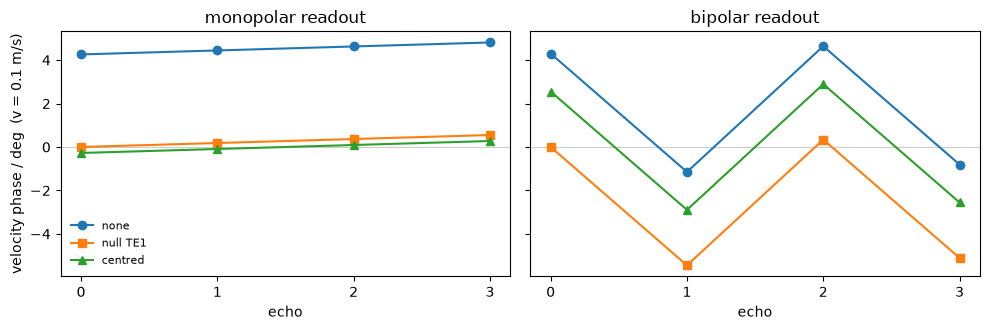

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(10.0, 3.4), sharey=True)
for ax, polarity in zip(axes, ('monopolar', 'bipolar')):
    bare = uncompensated[polarity][0]
    centre = 0.5 * (bare.max() + bare.min())
    echoes = np.arange(ECHOES)
    ax.axhline(0.0, color='0.8', lw=0.8)
    ax.plot(echoes, 360 * bare * V_M_S, 'o-', label='none')
    ax.plot(echoes, 360 * (bare - bare[0]) * V_M_S, 's-', label='null TE1')
    ax.plot(echoes, 360 * (bare - centre) * V_M_S, '^-', label='centred')
    ax.set_title(f'{polarity} readout')
    ax.set_xlabel('echo')
    ax.set_xticks(echoes)
axes[0].set_ylabel(f'velocity phase / deg  (v = {V_M_S} m/s)')
axes[0].legend(frameon=False, fontsize=8)
fig.tight_layout()
plt.show()

For the **monopolar** train the drift is small: nulling the first echo leaves 0.6° at the fourth,
against 4.8° uncompensated. Compensating the first echo is close to compensating the train, and
centring the excursion halves what is left.

For the **bipolar** train it is not. The alternation is an order of magnitude larger, and nulling
the first echo makes the **worst** echo worse than leaving it alone — 5.4° against 4.6° — because a
rigid shift cannot cancel an alternation, and moving echo 1 to zero moves echo 2 further away.
Centring is the best a single choice can do, and it still leaves 2.9° peak.

So the two polarities do not share a conclusion:

```text
monopolar   null at the first echo is a good approximation to nulling the train
bipolar     no single choice compensates the train; the alternation survives all of them
```

**Where a train could do better.** Making $M_1$ zero at *every* echo means $\mu_i = 0$ for every
interval — a condition on the inter-echo gradients themselves, not on anything before the first
echo. Whether there is room to impose it depends on whether those gradients have any freedom left,
and §3's event listing answers that: the monopolar train has a fly-back between consecutive
readout lobes, a region whose **area** is fixed by the need to return to the same $k_x$ but whose
**shape** is not. The bipolar train has none — its lobes are exactly contiguous, which is what
makes its echo spacing shorter, and there is no interval to reshape without changing the readout
itself. That asymmetry, rather than the size of the residual, is the substantive difference between
the two.

---

## Summary

A multi-echo gradient echo controls the zeroth gradient moment at every echo — $k_x$ returns to
zero on each traverse, $k_y$ and $k_z$ hold what the encoding set — and says nothing about the
first. Measured on the emitted waveform of a four-echo train, uncompensated, the first moment on
the readout axis climbs monotonically under a monopolar readout and alternates under a bipolar one,
while on the phase-encode and slice axes it is a single constant.

Asking for flow compensation nulls $M_1$ at the **first** echo. On `y` and `z` that compensates
every echo, because those axes are silent from before the first echo until after the last, and a
first moment about a fixed origin stops accruing where the gradient is zero. On `x` it compensates
the first echo only.

Between echoes the moments obey $M_0^{(i+1)} = M_0^{(i)}$ and
$M_1^{(i+1)} = M_1^{(i)} + \mu_i$, where $\mu_i$ is the first moment of the inter-echo waveform
about its own start. The lever-arm term drops out because each echo is a $k_x = 0$ crossing, so the
interval has zero net area — which makes $\mu_i$ independent of the origin and of the echo time.
Measured, it is: the increments are unchanged to nine digits between two trains whose first echoes
are a millisecond apart. Under a monopolar readout $\mu_i$ is one constant and $M_1$ is an
arithmetic progression; under a bipolar readout it alternates between two values whose sum is not
zero, because the echoes of a bipolar train are spaced unevenly by two dwells.

Because the pre-echo gradients enter only as $M_1^{(0)}$, they shift the whole sequence of first
moments rigidly: the peak-to-peak spread across the train is identical with and without flow
compensation. "Flow compensated" is therefore a choice of offset — the first echo, a nominated
echo, or the centre of the excursion — and for a monopolar train nulling the first echo is nearly
as good as any, while for a bipolar train no offset removes the alternation, and nulling the first
echo makes the worst echo worse than doing nothing.

**What this notebook does not cover.** Image-level artefact reduction is not demonstrated — what is
measured is the velocity-dependent phase term on the emitted waveform. The model is first order,
constant velocity only; acceleration carries a second moment. Nulling $M_1$ at every echo, rather
than at one, is not built here: it would require the inter-echo intervals themselves to carry no
first moment, which the monopolar fly-back has the freedom to do and the bipolar readout does not.

## References

Bernstein, King and Zhou, *Handbook of MRI Pulse Sequences*, Elsevier 2004 — §9.2 on gradient
moment nulling, and §16.1 on multi-echo readout trains.

Wu, Liu, Buch, Ye, Cheng and Haacke, *A fully flow-compensated multiecho susceptibility-weighted
imaging sequence: The effects of acceleration and background field on flow compensation*, Magn
Reson Med 76(2):478-489, 2016 — compensating every echo of a multi-echo train, rather than the
first, and what it costs.

Pattany et al., *Motion artifact suppression technique (MAST) for MR imaging*, J Comput Assist
Tomogr 11(3):369-377, 1987 — the original description of first-moment nulling.